In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
print("All imports successful!")

All imports successful!


In [5]:
# ============================================================
# CELL 1 — Imports & configuration
# Industry practice: all imports at the top, never scattered
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Industry practice: define paths once, never hardcode them inline
RAW_DATA_PATH = Path('../data/raw/superstore.csv')
DB_PATH       = Path('../data/processed/superstore.db')
REPORT_PATH   = Path('../reports/')

print("Libraries loaded. Paths configured.")

Libraries loaded. Paths configured.


In [12]:
# ============================================================
# CELL 2 — Load the data
# ============================================================

RAW_DATA_PATH = r"C:\Users\shokd\Desktop\Superstore\sales-revenue-intelligence\data\train.csv"

df = pd.read_csv(
    RAW_DATA_PATH,
    encoding='latin-1',
    parse_dates=['Order Date', 'Ship Date']
)

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded: 9,800 rows × 18 columns


In [14]:
# ============================================================
# CELL 3 — The professional first-look checklist
# Every analyst runs these 6 checks before touching the data
# ============================================================

print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)

# 1. Shape
print(f"\nRows:    {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

# 2. Column names and data types
print("\nColumn info:")
print(df.dtypes.to_string())

# 3. Missing values — the most critical first check
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(2)
null_df = pd.DataFrame({'Missing Count': null_counts, 'Missing %': null_pct})
null_df = null_df[null_df['Missing Count'] > 0]

print(f"\nColumns with missing values: {len(null_df)}")
if len(null_df) > 0:
    print(null_df)
else:
    print("None found.")

# 4. Duplicate rows
dupes = df.duplicated().sum()
print(f"\nDuplicate rows: {dupes}")

# 5. Basic statistics for numeric columns
print("\nNumeric summary:")
print(df.describe().round(2).to_string())

# 6. First 3 rows to sanity-check structure
print("\nSample rows:")
print(df.head(3).to_string())

DATASET OVERVIEW

Rows:    9,800
Columns: 18

Column info:
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64

Columns with missing values: 1
             Missing Count  Missing %
Postal Code             11       0.11

Duplicate rows: 0

Numeric summary:
        Row ID  Postal Code     Sales
count  9800.00      9789.00   9800.00
mean   4900.50     55273.32    230.77
std    2829.16     32041.22    626.65
min       1.00      1040.00      0.44
25%    2450.75     23223.00     17.25
50%    4900.50     58103.00     54.49
75%    7350.25     90008.00    210.60
max    9800.00     99301.00  22638.48

Sam

In [20]:
# ============================================================
# CELL 4 — Data cleaning (professional style)
# Work on a copy, never mutate the raw data
# ============================================================

df_clean = df.copy()

# --- 1. Standardise column names ---
# Spaces in column names cause bugs in SQL and pandas chaining
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('-', '_')
)
print("Columns standardised:", df_clean.columns.tolist())

# --- 2. Parse date columns, extract features ---
df_clean['order_date'] = pd.to_datetime(df_clean['order_date'])
df_clean['ship_date']  = pd.to_datetime(df_clean['ship_date'])

df_clean['order_year']    = df_clean['order_date'].dt.year
df_clean['order_month']   = df_clean['order_date'].dt.month
df_clean['order_quarter'] = df_clean['order_date'].dt.quarter
df_clean['ship_days']     = (df_clean['ship_date'] - df_clean['order_date']).dt.days

print("\nDate features created.")

# --- 3. Check for business logic violations ---
# A ship date BEFORE the order date is impossible — catch it
invalid_ship = df_clean[df_clean['ship_days'] < 0]
print(f"Orders with negative ship days (data error): {len(invalid_ship)}")

# Negative profit is valid (discounts can cause losses) — but flag it
negative_profit = df_clean[df_clean['profit'] < 0]
print(f"Orders with negative profit: {len(negative_profit)} "
      f"({len(negative_profit)/len(df_clean)*100:.1f}%)")

# --- 4. Create a derived metric: profit margin ---
# This is a KEY business metric — never just use raw profit
df_clean['profit_margin'] = (df_clean['profit'] / df_clean['sales']).round(4)

# --- 5. Drop true duplicates (if any found earlier) ---
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after  = len(df_clean)
print(f"\nRows removed as duplicates: {before - after}")

print(f"\nClean dataset shape: {df_clean.shape}")

Columns standardised: ['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales']


ValueError: time data "15/04/2018" doesn't match format "%m/%d/%Y". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [21]:
# ============================================================
# CELL 5 — Load cleaned data into SQLite
# This is what makes your project industry-grade
# ============================================================

conn = sqlite3.connect(DB_PATH)

df_clean.to_sql(
    name='orders',
    con=conn,
    if_exists='replace',   # replace table if it already exists
    index=False            # don't write the pandas index as a column
)

# Verify the load
cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM orders")
row_count = cursor.fetchone()[0]
print(f"Loaded {row_count:,} rows into SQLite → table: 'orders'")

# Always close your connection when done writing
conn.close()
print("Database connection closed.")

Loaded 9,800 rows into SQLite → table: 'orders'
Database connection closed.


In [22]:
print(df_clean['order_date'].head(10))
df_clean['order_date'] = pd.to_datetime(
    df_clean['order_date'],
    errors='coerce'
)

df_clean['ship_date'] = pd.to_datetime(
    df_clean['ship_date'],
    errors='coerce'
)
print(df_clean[df_clean['order_date'].isna()])
print(df_clean.columns.tolist())

0    08/11/2017
1    08/11/2017
2    12/06/2017
3    11/10/2016
4    11/10/2016
5    09/06/2015
6    09/06/2015
7    09/06/2015
8    09/06/2015
9    09/06/2015
Name: order_date, dtype: str
      row_id        order_id order_date  ship_date       ship_mode  \
12        13  CA-2018-114412        NaT        NaT  Standard Class   
14        15  US-2016-118983        NaT        NaT  Standard Class   
15        16  US-2016-118983        NaT        NaT  Standard Class   
17        18  CA-2015-167164        NaT        NaT    Second Class   
18        19  CA-2015-143336        NaT 2015-01-09    Second Class   
...      ...             ...        ...        ...             ...   
9791    9792  CA-2015-127166        NaT        NaT    Second Class   
9792    9793  CA-2015-127166        NaT        NaT    Second Class   
9793    9794  CA-2015-127166        NaT        NaT    Second Class   
9794    9795  CA-2015-127166        NaT        NaT    Second Class   
9795    9796  CA-2017-125920        NaT  

KeyError: 'order_year'

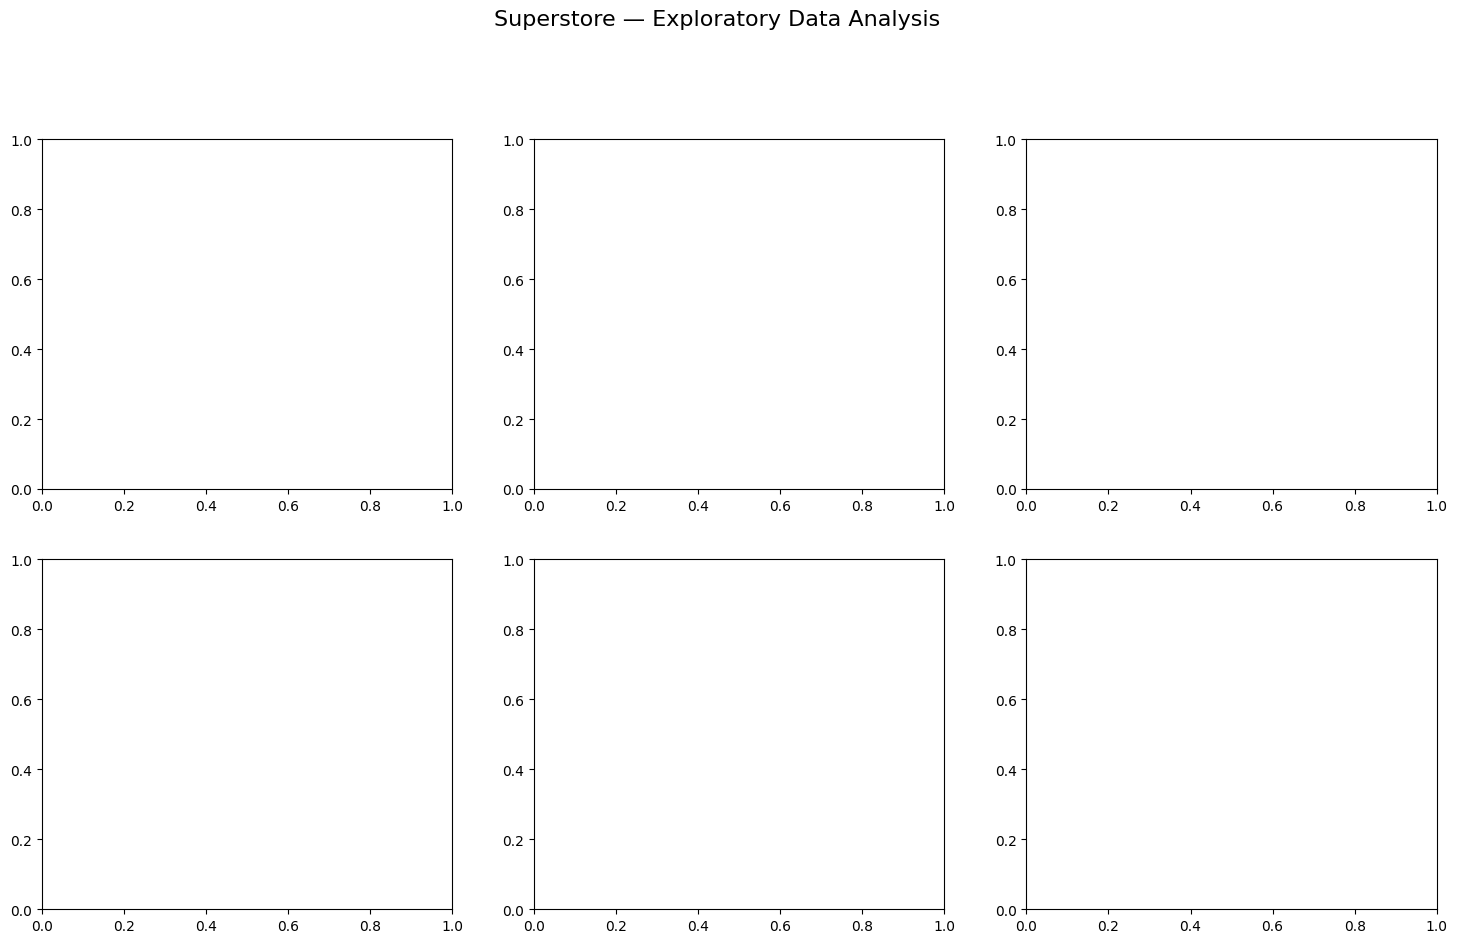

In [23]:
# ============================================================
# CELL 6 — Visual EDA: the 5 charts every analyst makes first
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Superstore — Exploratory Data Analysis', fontsize=16, y=1.01)

# Chart 1: Revenue by year
yearly = df_clean.groupby('order_year')['sales'].sum()
axes[0,0].bar(yearly.index, yearly.values, color='steelblue')
axes[0,0].set_title('Revenue by Year')
axes[0,0].set_ylabel('Sales ($)')
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# Chart 2: Sales by category
cat_sales = df_clean.groupby('category')['sales'].sum().sort_values()
axes[0,1].barh(cat_sales.index, cat_sales.values, color='teal')
axes[0,1].set_title('Sales by Category')
axes[0,1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# Chart 3: Profit margin distribution
axes[0,2].hist(df_clean['profit_margin'], bins=40, color='coral', edgecolor='white')
axes[0,2].set_title('Profit Margin Distribution')
axes[0,2].set_xlabel('Profit Margin')
axes[0,2].axvline(0, color='red', linestyle='--', label='Break-even')
axes[0,2].legend()

# Chart 4: Monthly sales trend
monthly = df_clean.groupby(['order_year','order_month'])['sales'].sum().reset_index()
monthly['period'] = pd.to_datetime(monthly[['order_year','order_month']].assign(day=1))
axes[1,0].plot(monthly['period'], monthly['sales'], color='steelblue', linewidth=1.5)
axes[1,0].set_title('Monthly Revenue Trend')
axes[1,0].set_ylabel('Sales ($)')
axes[1,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# Chart 5: Discount vs Profit scatter
axes[1,1].scatter(df_clean['discount'], df_clean['profit'],
                  alpha=0.3, s=10, color='purple')
axes[1,1].set_title('Discount vs Profit')
axes[1,1].set_xlabel('Discount Rate')
axes[1,1].set_ylabel('Profit ($)')
axes[1,1].axhline(0, color='red', linestyle='--')

# Chart 6: Top 10 sub-categories by revenue
sub_sales = df_clean.groupby('sub_category')['sales'].sum().nlargest(10)
axes[1,2].barh(sub_sales.index, sub_sales.values, color='goldenrod')
axes[1,2].set_title('Top 10 Sub-Categories')
axes[1,2].invert_yaxis()

plt.tight_layout()
plt.savefig(REPORT_PATH / 'eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports/eda_overview.png")

In [24]:
print(df_clean.columns.tolist())


['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales']


In [26]:
df_clean['order_date'] = pd.to_datetime(
    df_clean['order_date'],
    errors='coerce'
)

df_clean['ship_date'] = pd.to_datetime(
    df_clean['ship_date'],
    errors='coerce'
)

df_clean['order_year'] = df_clean['order_date'].dt.year

KeyError: 'profit_margin'

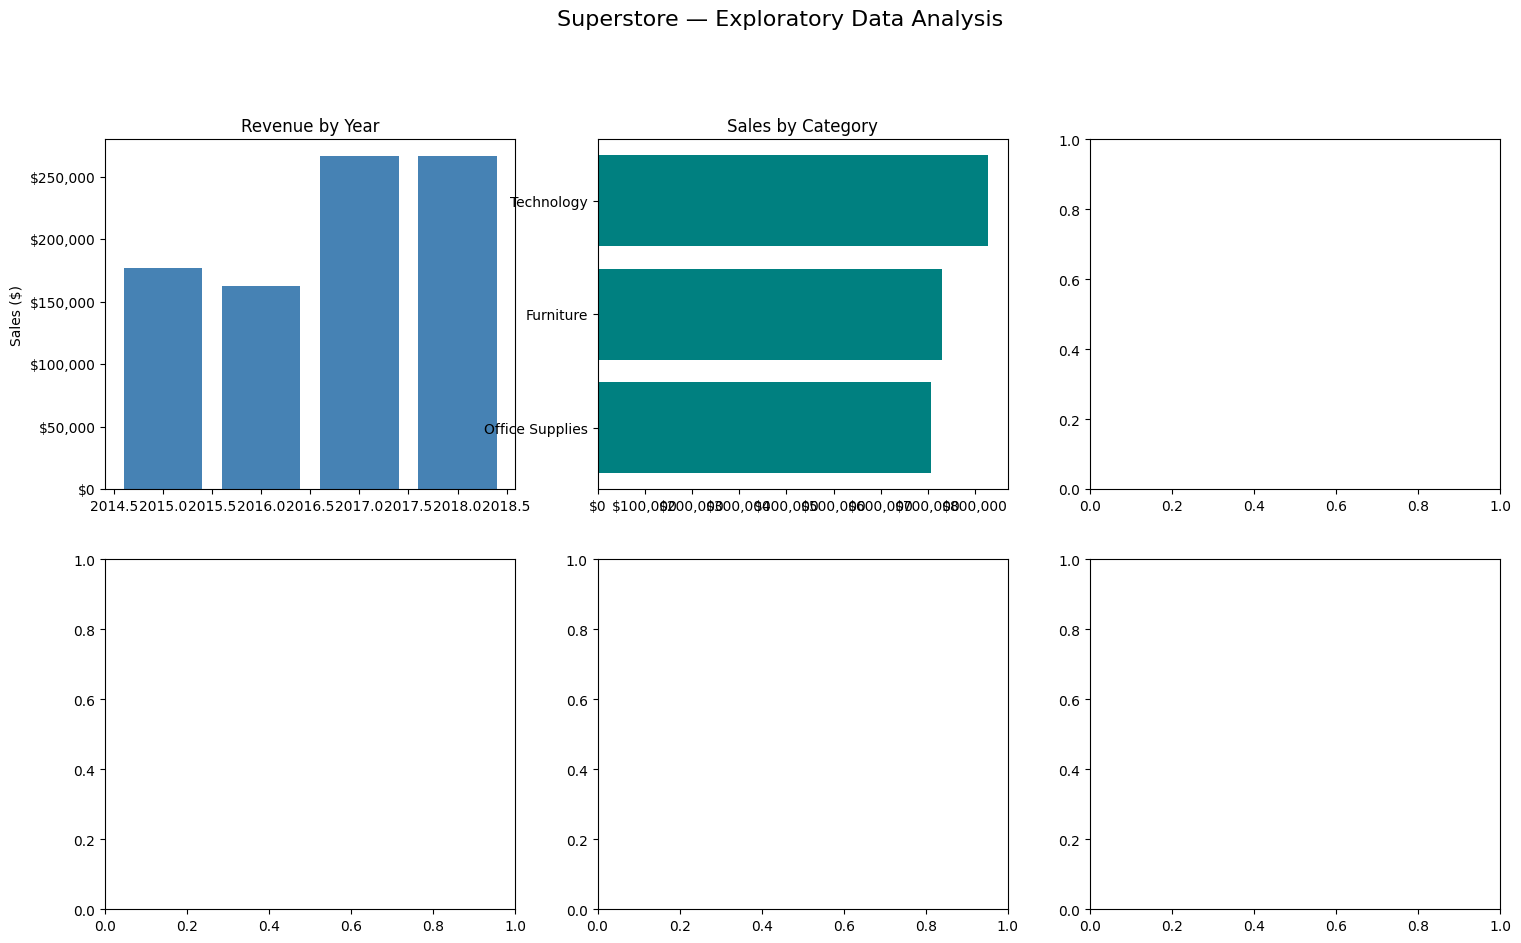

In [28]:
# ============================================================
# CELL 6 — Visual EDA: the 5 charts every analyst makes first
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Superstore — Exploratory Data Analysis', fontsize=16, y=1.01)

# Chart 1: Revenue by year
yearly = df_clean.groupby('order_year')['sales'].sum()
axes[0,0].bar(yearly.index, yearly.values, color='steelblue')
axes[0,0].set_title('Revenue by Year')
axes[0,0].set_ylabel('Sales ($)')
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# Chart 2: Sales by category
cat_sales = df_clean.groupby('category')['sales'].sum().sort_values()
axes[0,1].barh(cat_sales.index, cat_sales.values, color='teal')
axes[0,1].set_title('Sales by Category')
axes[0,1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# Chart 3: Profit margin distribution
axes[0,2].hist(df_clean['profit_margin'], bins=40, color='coral', edgecolor='white')
axes[0,2].set_title('Profit Margin Distribution')
axes[0,2].set_xlabel('Profit Margin')
axes[0,2].axvline(0, color='red', linestyle='--', label='Break-even')
axes[0,2].legend()

# Chart 4: Monthly sales trend
monthly = df_clean.groupby(['order_year','order_month'])['sales'].sum().reset_index()
monthly['period'] = pd.to_datetime(monthly[['order_year','order_month']].assign(day=1))
axes[1,0].plot(monthly['period'], monthly['sales'], color='steelblue', linewidth=1.5)
axes[1,0].set_title('Monthly Revenue Trend')
axes[1,0].set_ylabel('Sales ($)')
axes[1,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# Chart 5: Discount vs Profit scatter
axes[1,1].scatter(df_clean['discount'], df_clean['profit'],
                  alpha=0.3, s=10, color='purple')
axes[1,1].set_title('Discount vs Profit')
axes[1,1].set_xlabel('Discount Rate')
axes[1,1].set_ylabel('Profit ($)')
axes[1,1].axhline(0, color='red', linestyle='--')

# Chart 6: Top 10 sub-categories by revenue
sub_sales = df_clean.groupby('sub_category')['sales'].sum().nlargest(10)
axes[1,2].barh(sub_sales.index, sub_sales.values, color='goldenrod')
axes[1,2].set_title('Top 10 Sub-Categories')
axes[1,2].invert_yaxis()

plt.tight_layout()
plt.savefig(REPORT_PATH / 'eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports/eda_overview.png")

In [30]:
df_clean['profit_margin'] = (
    df_clean['profit'] / df_clean['sales']
) * 100

KeyError: 'profit'

In [31]:
print(df_clean.columns.tolist())


['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'order_year']


In [32]:
total_sales = df_clean['sales'].sum()
avg_order_value = df_clean['sales'].mean()
total_orders = df_clean['order_id'].nunique()
total_customers = df_clean['customer_id'].nunique()

print("Total Sales:", total_sales)
print("Average Order Value:", avg_order_value)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)

Total Sales: 2261536.7827
Average Order Value: 230.76905945918367
Total Orders: 4922
Total Customers: 793


In [ ]:
yearly = df_clean.groupby('order_year')['sales'].sum()

In [34]:
import sweetviz as sv
from pathlib import Path

REPORT_PATH = Path("reports")
REPORT_PATH.mkdir(exist_ok=True)

report = sv.analyze(df_clean)

report.show_html(
    filepath=str(REPORT_PATH / "eda_report.html"),
    open_browser=False
)

print("EDA report generated successfully.")

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)


Report reports\eda_report.html was generated.
EDA report generated successfully.
